<center><h1>Programmation linéaire en nombre entiers</h1></center>


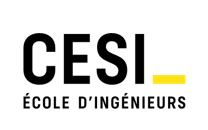

<blockquote>
    <table >
        <tr>
            <th style="text-align:center;">Version</th>
            <th style="text-align:center;">Date</th>
            <th style="text-align:left;">Concepteur</th>
            <th style="text-align:left;">Relecteur </th>
            <th style="text-align:left;">Commentaires</th>
        </tr><tr>
            <td style="text-align:center;">1.0</td>
            <td style="text-align:center;">Juin 2022</td>
            <td style="text-align:left;"><a href="mailto:mguiraud@cesi.fr">Maël Guiraud</a></td>
            <td style="text-align:left;"></td>
            <td style="text-align:left;">Version initiale.</td>
        </tr>
        <tr>
            <td style="text-align:center;">2.0</td>
            <td style="text-align:center;">2025-01-23</td>
            <td style="text-align:left;"><a href="mailto:mguiraud@cesi.fr">Maël Guiraud</a></td>
            <td style="text-align:left;"></td>
            <td style="text-align:left;">Adaptation format corbeille.</td>
        </tr>
    </table>
<h2>Compétences de la corbeille</h2>
<ul>
    <li>Expliquer le principe de la relaxation continue dans l'utilisation des méthodes arborescentes</li>
    <li>Démontrer le lien entre PLNR et PLNE (notion de bornes)</li>
    <li>Déterminer une borne à l'aide de la relaxation continue</li>
    <li>Appliquer une méthode de relaxation continue dans l'utilisation d'une méthode arborescente (Branch & Bound)</li>
</ul>
 

<h2>Objectifs</h2>
Nous reprenons dans cette corbeille le problème du sac à dos du prosit précédent pour le résoudre à l'aide de la PLNE.
Dans un premier temps, un branch and bound est déroulé sur une instance simple, dans le but de bien comprendre la relaxation continue.
Ensuite, on utilise directement la librairie pulp qui est interfacé avec des solveurs très performants pour résoudre le problème.
  
<h2>Philosophie et recommandations</h2>
L'objectif est de faire comprendre aux étudiants l'utilité de la relaxation continue pour la PLNE : On utilise la solution optimale du programme linéaire relaxé (sans la contrainte d'intégrité des variables) pour trouver une borne à la solution.

    
</blockquote>

Lors de cette corbeille, vous allez découvrir les principaux outils qui servent à résoudre un programme linéaire en nombre entiers.
Nous allons revenir sur le fait qu'il est impossible d'utiliser l'algorithme du simplexe pour résoudre un PLNE, et montrer comment utiliser ce dernier dans l'algorithme classique de résolution d'un PLNE, le Branch and Bound.


# 1 - Que peut-on tirer de la résolution par la méthode du simplexe?

Pour commencer nous considérerons le problème suivant. 
Un jardinier cherche du terreau pour faire pousser ses plantes. Il se rend chez son pépiniériste préféré pour faire ses achats.
Il souhaiterait ramener le plus de terreau possible pour faire un stock. Il dispose d'une remorque dans laquelle il sait qu'il peut stocker sa terre sans problèmes. Deux modèles lui sont proposés. Un premier terreau à 10€ le litre, et un second terreau à 12€ le litre. Le premier terreau se vend par sac de 10 litres tandis que le second se vend par sac de 11 litres. Notre jardinier dispose d'un budget de 59€.

Écrivez le PL.

<blockquote>
Le programme linéaire est le suivant.

$\max 10x_1 + 11x_2$
$sc. 10x_1 + 12 x_2 \leq 59\\
x_1,x_2 \geq 0\\
x_1,x_2 \in \mathbb{N}$
    
Les étudiants pourraient identifier le problème du sac à dos, mais le but n'est pas de perdre du temps sur cette question.
</blockquote>


Comme nous l'avons vu dans le prosit précédent, nous ne pouvons résoudre le problème à l'aide de la méthode du simplexe que si nous choisissons de ne pas tenir compte de la contrainte d'intégrité des variables. Ignorer cette contrainte consiste à faire une <b>relaxation continue</b> du problème.


Vous avez ci-dessous la résolution graphique du problème relaxé.
Quel est le domaine des solutions réalisables? Que représentent les droites rouges et bleues ? Quelle semble être la solution optimale pour le programme linéaire ?
<blockquote>
Cette question n'est qu'un rappel des séances précédentes. Le domaine des solutions réalisable est le triangle blanc, la contrainte est représentée par la droite rouge et la fonction économique par la droite bleue. La solution optimale est $x_1 = 5,9$ et $x_2 = 0$. Il est important de rappeler que c'est la solution du programme linéaire sans la contrainte d'intégrité sur les variables $x_1$ et $x_2$.
</blockquote>


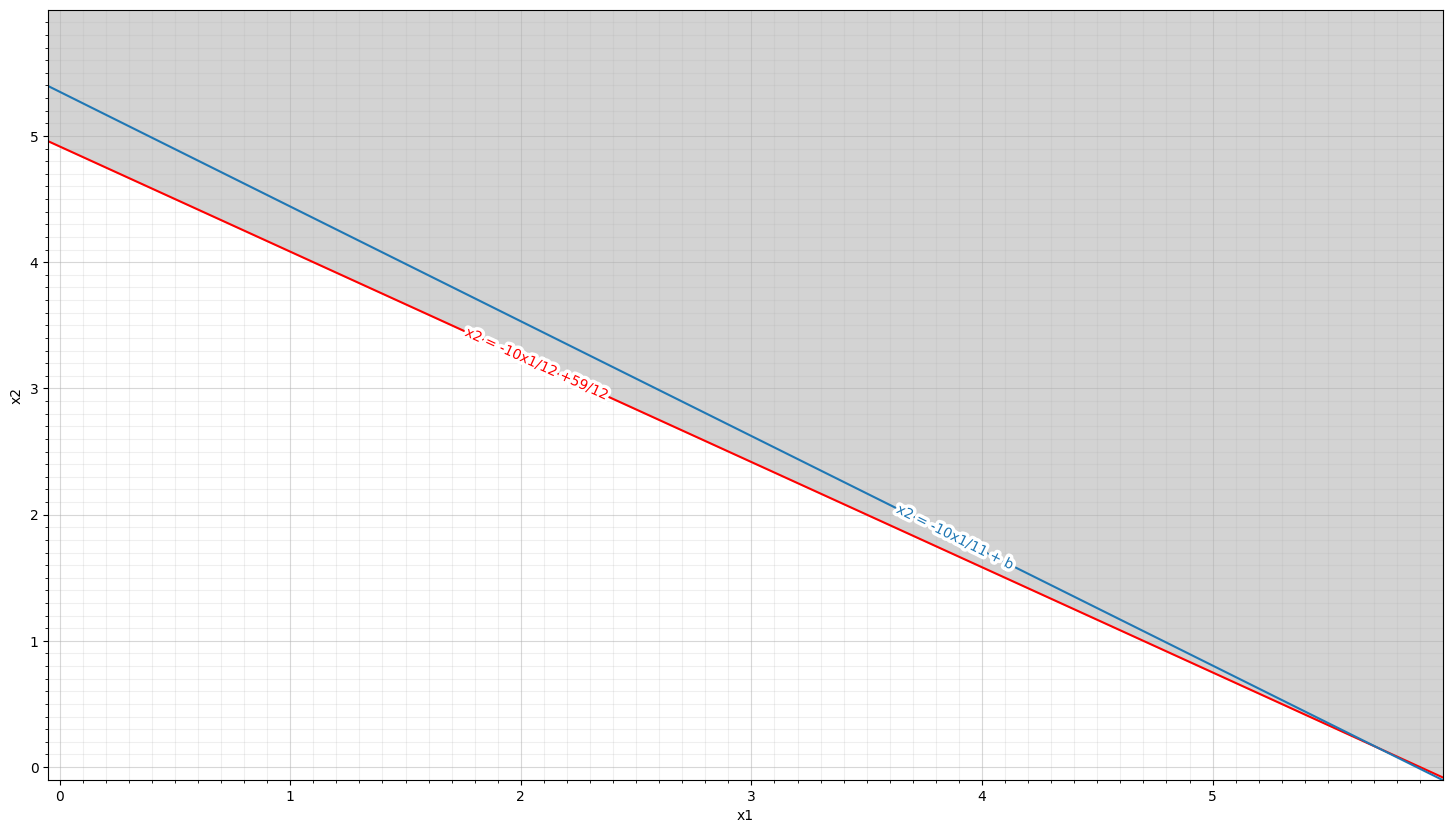

In [5]:
####################################################A EXECUTER##################################################
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np
try:
    import matplotlib.pyplot as plt
except:
    !pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from labellines import labelLine, labelLines
except:
    !pip install matplotlib-label-lines
    from labellines import labelLine, labelLines

    
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
x = np.linspace(-1, 7, 8)
y2 = 59/12-(10/12)*x
plt.plot(x, y2, color='red',label = "x2 = -10x1/12 +59/12")                    
plt.fill_between(x, y2, 10, color='lightgrey') 


plt.ylim(-0.1, 6)
plt.xlim(-0.05,6)

pente = -10/11      
yeco = (x*pente)+5.35
plt.plot(x, yeco,label = "x2 = -10x1/11 + b")
plt.gcf().set_size_inches(18,10)
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
minticks =np.arange(0,6,0.1)
majticks = np.arange(0,6,1)

ax.set_xticks(majticks)
ax.set_xticks(minticks, minor=True)
ax.set_yticks(majticks)
ax.set_yticks(minticks, minor=True)
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)
labelLines(ax.get_lines(), zorder=2.5)
plt.show()


Comme vous le savez déjà, cette solution n'est pas une solution à notre problème en nombre entiers (il serait étonnant que le pépiniériste accepte que notre jardinier laisse 10% d'un sac en vrac dans le magasin). Malgré tout, que pouvons-nous obtenir comme information de cette solution ?
<blockquote>
La valeur de la solution optimale du problème relaxé est une borne supérieure sur la valeur de la solution optimale du PLNE. En effet, étant donné que les solutions entières de ces problèmes se trouvent à l'intérieur du polytope, la valeur de la solution entière est forcément inférieure ou égale à celle de la solution du problème relaxée, qui elle se trouve sur un sommet du polytope.
</blockquote>

Quelle idée, plutôt intuitive vous vient à l'esprit pour obtenir une solution entière à partir de la solution du problème relaxée.
<blockquote>
Beaucoup seraient tenter de penser qu'un arrondi au plus proche (ici inférieur) de la valeur des variables de la solution optimale du problème relaxé donnerait la solution optimale du problème entier. En revanche, ici ce n'est même pas le cas, la solution optimale du PLNE est $x_1=1$ et $x_2=4$.

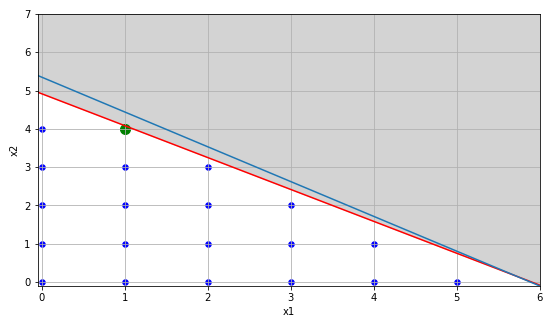
    
Il est même possible, comme sur la figure ci-dessous, qu'il ne soit pas possible d'arrondir la valeur des variables de la solution optimale du problème relaxé. En effet, un arrondi, aussi bien à l'entier inférieur que supérieur de la variable représentée en ordonnée ne donne pas une solution réalisable.
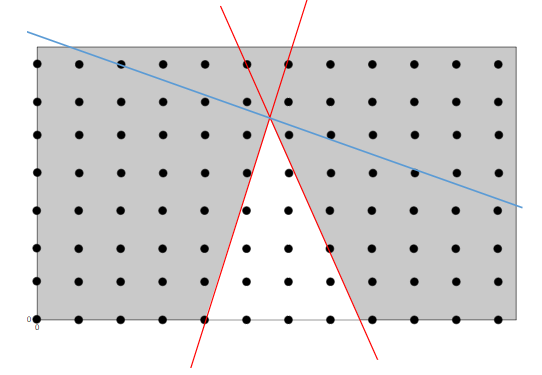
</blockquote>


# 2- Espace des solutions

Bien que la relaxation continue d'un PLNE nous donne une borne sur la solution optimale, il n'est pas possible directement d'en tirer cette solution. La méthode la plus simple pour nous reste encore d'essayer toutes les valeurs pour $x_1$ et $x_2$ et de garder celles qui maximisent la valeur de la fonction économique.

Quelles sont les solutions réalisables pour ce problème? Pouvez-vous les représenter sur le graphique précédent?
Quel est l'intervalle des valeurs que peuvent prendre $x_1$ et $x_2$ pour rester dans l'espace des solutions réalisables?
En remplissant les valeurs max pour $x_1$ et $x_2$, exécutez le code ci-dessous pour voir l'arbre de recherche exhaustive sur l'ensemble des solutions.
<blockquote>
    Les étudiants peuvent se servir de la résolution graphique pour identifier les solutions réalisables du PLNE. En effet, on identifie assez facilement que $x_1$ peut prendre des valeurs jusqu'a $5$ et $x_2$ peut aller jusqu'à $4$
    

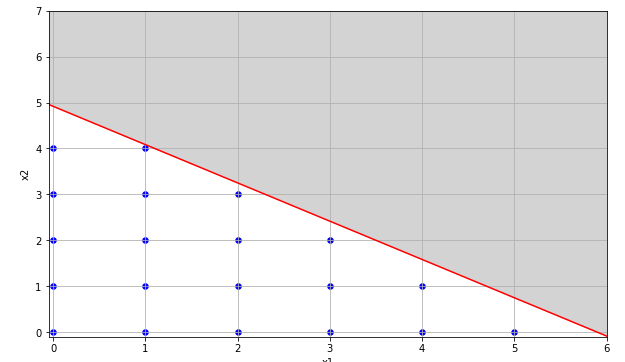
</blockquote>

In [21]:
x1max=5 #SOLUTION
x2max=4 #SOLUTION

In [26]:
import plotly.graph_objects as go

def dessine_arbre_terreau(x, y, num_obj, xmax, profondeur_max,
                          parent_index=None, positions=None, connections=None):
    """
    Génére un arbre de profondeur `profondeur_max`.
    Chaque niveau `num_obj` correspond à x<num_obj>, et on prend toutes
    les quantités possibles de 0 à xmax[num_obj-1].
    positions : liste des noeuds -> (x_coord, y_coord, obj, qty)
    connections : liste de tuples (child, parent)
    """
    if positions is None:
        positions = []
    if connections is None:
        connections = []

    # Cas d'arrêt
    if num_obj > profondeur_max:
        return

    # On place ce niveau à -num_obj en y
    y_level = -num_obj
    
    # On parcourt chaque quantité
    for qty in range(xmax[num_obj - 1] + 1):
        node_index = len(positions)
        
        # On met x=node_index pour avoir un écart horizontal
        positions.append((node_index, y_level, num_obj, qty))
        
        if parent_index is not None:
            connections.append((node_index, parent_index))
        
        # Recursion
        dessine_arbre_terreau(node_index, y_level, num_obj + 1, xmax,
                              profondeur_max, node_index, positions, connections)

def admissible(solution):
    """
    Contrôle la contrainte : 10*x1 + 12*x2 <= 59.
    solution = [x1, x2] si 2 variables
    """
    x1, x2 = solution[0], solution[1]
    total = 10 * x1 + 12 * x2
    return (total <= 59)

# ==================
# PARAMETRES
# ==================
x1max = 3
x2max = 5
xmax = [x1max, x2max]       # seulement 2 variables
profondeur_max = len(xmax)  # = 2

# ==================
# CONSTRUCTION DE L'ARBRE
# ==================
positions = []
connections = []

# On ajoute la racine manuellement (obj=0 => racine)
positions.append((0, 0, 0, 0))  # (x=0, y=0, obj=0 => racine, qty=0)
root_index = 0

# On lance la construction de l'arbre à partir du niveau 1
dessine_arbre_terreau(0, 0, 1, xmax, profondeur_max,
                      root_index, positions, connections)

x_coords, y_coords, objets, quantites = zip(*positions)

# ==================
# COLORIAGE AVEC DEBUG
# ==================
colors = []
debug_info = []  # Pour traquer les solutions
for node_idx, (obj, qty) in enumerate(zip(objets, quantites)):
    if obj == 0:
        # Racine
        colors.append("blue")
        debug_info.append(f"Node={node_idx} [Racine], pas de solution à tester")
    else:
        # Reconstituer la solution
        solution = [0]*profondeur_max
        curr_idx = node_idx
        
        while True:
            cur_obj = objets[curr_idx]
            cur_qty = quantites[curr_idx]
            if cur_obj > 0:  # obj=0 => racine
                solution[cur_obj-1] = cur_qty
            
            # Cherche le parent
            parent = None
            for (child, par) in connections:
                if child == curr_idx:
                    parent = par
                    break
            
            if parent is None:
                break
            curr_idx = parent
        
        # Test
        is_ok = admissible(solution)
        if is_ok:
            colors.append("green")
        else:
            colors.append("red")
        debug_info.append(f"Node={node_idx} => solution={solution}, admissible={is_ok}")


# ==================
# CONSTRUCTION DES ARÊTES
# ==================
edges_x = []
edges_y = []
for (child_idx, parent_idx) in connections:
    cx, cy, _, _ = positions[child_idx]
    px, py, _, _ = positions[parent_idx]
    edges_x += [cx, px, None]
    edges_y += [cy, py, None]

fig = go.Figure()

# Tracer les connections
fig.add_trace(go.Scatter(
    x=edges_x, y=edges_y,
    mode='lines',
    line=dict(color='black', width=1),
    hoverinfo='none'
))

# Tracer les noeuds
fig.add_trace(go.Scatter(
    x=list(x_coords),
    y=list(y_coords),
    mode='markers+text',
    marker=dict(size=10, color=colors),
    text=[("Racine" if o == 0 else f"x{o}={q}") 
          for (o, q) in zip(objets, quantites)],
    textposition="top center",
    hoverinfo='text'
))

fig.update_layout(
    title="Arbre x1,x2",
    showlegend=False,
    xaxis=dict(showline=False, zeroline=False, showgrid=False, visible=False),
    yaxis=dict(showline=False, zeroline=False, showgrid=False, visible=False),
    xaxis_range=[-1, len(positions)+1],
    yaxis_range=[-(profondeur_max + 1), 1],
    plot_bgcolor='white'
)

fig.show()


Que représente une feuille de l'arbre?
<blockquote>
Chaque feuille représente un choix différent de valeur pour les variables $x_1$ et $x_2$, donc une solution pour notre problème.
</blockquote>

Combien de feuilles comptez-vous à cet arbre? En généralisant sur $k$ variables dont les valeurs peuvent prendre respectivement $n_k$ valeurs, combien de feuilles comporterait l'arbre?

<blockquote>
    Il y a $6 \times 5 = 30$ feuilles. Dans le cas général, on obtient au pire $\prod_{i=0}^k n_i$ feuilles.
</blockquote>

Comme vous le remarquez, certaines feuilles sont rouges. A votre avis, que représentent ces feuilles? Pouvez-vous les représenter sur la résolution graphique de la partie 1?

<blockquote>
    Ce sont les solutions non réalisables. En rouge sur la figure suivante.
    

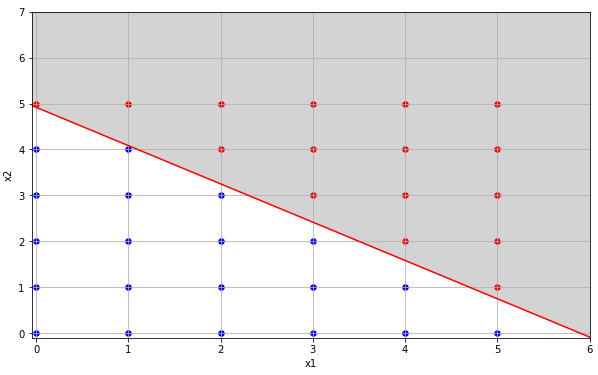

</blockquote>

Il est donc inutile de visiter ces feuilles. 
Poussons le raisonnement un peu plus loin, et ajoutons une troisième variable à notre problème tel que le programme linéaire soit le suivant.

$\max 10x_1 + 11x_2+ 9x_3$
$sc. 10x_1 + 12 x_2 + 7 x_3\leq 59\\
x_1,x_2,x_3 \geq 0\\
x_1,x_2,x_3 \in \mathbb{N}$

A 3 variables, il est toujours possible d'afficher une représentation graphique de l'espace des solutions réalisables et que nous soyons en mesure de l'interpréter.
En effet, les solutions réalisables sont dans le polyèdre dont les faces sont les trois plans $x_1=0$,$x_2=0$ et $x_3=0$ et le plan défini par $x_3 = \frac{59-10x_1+12x_2}{7}$.

Exécutez le code ci-dessous pour visualiser le polyèdre. Vous pouvez faire bouger le graphique 3D pour bien visualiser l'espace de solutions.

In [38]:
%matplotlib notebook
## SI cela n'affiche rien, remplacez par %matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d  # Pour l'affichage 3D
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# Création du maillage pour x1 et x2 (axes 0 et 1)
xx, yy = np.meshgrid(range(6), range(6))

# Calcul de x3 en fonction de x1 et x2
z = (59 - 10*xx - 12*yy) / 7

# --- Tracé du résultat en 3D ---
fig = plt.figure()
# Au lieu de fig.gca(projection='3d'), on fait :
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, z, linewidth=0, alpha=0.5)
plt.title("Tracé d'une surface")
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')

# Limites en z (optionnel)
ax.set_zbound(lower=0, upper=6)
plt.tight_layout()

# Création d'un maillage 3D pour x1, x2 et x3
xx3, yy3, zz3 = np.meshgrid(range(6), range(6), range(10))

# Séparation des points admissibles (bleus) et non admissibles (rouges)
cond = 10*xx3 + 12*yy3 + 7*zz3 <= 59
Xblue = xx3[cond]
Yblue = yy3[cond]
Zblue = zz3[cond]

Xred = xx3[~cond]
Yred = yy3[~cond]
Zred = zz3[~cond]

ax.scatter(Xblue, Yblue, Zblue, marker='o', s=30, color='blue')
ax.scatter(Xred, Yred, Zred, marker='o', s=30, color='red')
ax.set_zlim3d(0, 9)

plt.show()


<IPython.core.display.Javascript object>

Que représentent un point sur cette figure ? Les points rouges? Les points bleus ?
<blockquote>
Les points représentent les solutions entières réalisables ou non dans l'ensemble des solutions dont les valeurs de $x_1,x_2$ où $x_3$ vont entre $0$ et $5$, c'est à dire, l'ensemble des points dont les coordonnées sont entières et sont comprises entre $0$ et $5$. Les points bleus sont les solutions réalisables, et les points rouges sont les solutions non réalisables (i.e. qui ne respectent pas la contrainte).
</blockquote>

Pouvez-vous identifier l'ensemble des points visités par la recherche exhaustive du problème dans lequel on ne considère pas $x_3$ ?
<blockquote>
C'est le plan défini par $x_3=0$.
</blockquote>

On identifie assez simplement avec le graphique (où même par un simple calcul : $59/7$) que $x_3$ peut prendre pour valeur maximale $8$. 
Si on veut re-dessiner notre arbre qui énumère toutes les solutions (recherche exhaustive), cela revient à rajouter un troisième niveau en considérant à chaque fois les valeurs de $x_3$ allant de $0$ à $8$, afin d'explorer l'espace de solution dans la dimension de $x_3$

Le code ci-dessous reprend et affiche l'arbre de recherche exhaustive, avec 3 variables.
Étant donné qu'il y a énormément de nœud, c'est très brouillon, en baissant x3max à 2, vous pourrez voir plus clairement l'arbre.


In [14]:
x3max =\
8 #SOLUTION

In [32]:
try:
    import plotly.graph_objects as go
except:
    !pip install plotly
    !pip install "ipywidgets>=7.5"
    import plotly.graph_objects as go

# Fonction récursive pour générer l'arbre
def dessine_arbre_terreau(x, y, num_obj, xmax, profondeur_max, parent_index=None, positions=[], connections=[]):
    """
    Génère un arbre où chaque niveau représente le choix d'une quantité pour un type de terreau.
    - x, y : Position actuelle du nœud
    - num_obj : Numéro du type de terreau actuel (x1, x2, ...)
    - xmax : Liste des quantités maximales pour chaque type de terreau (ex : [x1max, x2max, ...])
    - profondeur_max : Nombre total de types de terreau
    - parent_index : Index du parent (pour relier les nœuds)
    - positions : Liste des positions des nœuds
    - connections : Liste des relations parent-enfant
    """
    if num_obj > profondeur_max:  # Arrêt quand tous les types de terreau ont été parcourus
        return
    
    # Créer les nœuds pour chaque quantité de sacs
    y_pos = -num_obj  # La position verticale est déterminée par le niveau
    for i in range(xmax[num_obj - 1] + 1):  # Parcourir les quantités possibles (0 à xmax[num_obj - 1])
        x_pos = len(positions)  # Position horizontale basée sur l'ordre des nœuds
        
        positions.append((x_pos, y_pos, num_obj, i))  # Ajouter le nœud avec ses détails
        if parent_index is not None:
            connections.append((len(positions) - 1, parent_index))  # Relier au parent
        
        # Appel récursif pour le niveau suivant
        dessine_arbre_terreau(x_pos, y_pos, num_obj + 1, xmax, profondeur_max, len(positions) - 1, positions, connections)

# Fonction pour vérifier si une solution est admissible
def admissible(solution):
    """
    Retourne True si la combinaison des sacs est faisable (admissible), False sinon.
    - solution : Liste des quantités pour chaque variable [x1, x2, ...]
    """
    total_volume = 10 * solution[0] + 12 * solution[1]  # Exemple avec deux variables (x1 et x2)
    if len(solution) > 2:
        total_volume += 7 * solution[2]  # Ajouter une contrainte pour x3 si présente
    return total_volume <= 59

# Initialisation des paramètres
xmax = [x1max, x2max, x3max]  # Liste des quantités maximales pour x1, x2, x3
profondeur_max = len(xmax)  # Nombre de types de terreau (profondeur de l'arbre)

positions = []
connections = []
# Ajouter la racine vide
racine_x, racine_y = 0, 0
positions.append((racine_x, racine_y, 0, 0))  # La racine est ajoutée en premier
# Relier la racine au premier niveau
dessine_arbre_terreau(racine_x, racine_y, 1, xmax, profondeur_max, 0, positions, connections)

# Séparer les coordonnées et les informations des nœuds
x_coords, y_coords, objets, quantites = zip(*positions)

# Déterminer les couleurs en fonction de l'admissibilité
colors = []
for index, (obj, qty) in enumerate(zip(objets, quantites)):
    if obj == 0:  # La racine
        colors.append("blue")
    else:
        # Reconstituer la solution pour le nœud courant
        solution = [0] * profondeur_max
        current_index = index
        while current_index is not None:
            current_obj = objets[current_index]
            current_qty = quantites[current_index]
            solution[current_obj - 1] = current_qty
            # Trouver le parent
            current_index = next((parent for child, parent in connections if child == current_index), None)
        
        # Vérifier l'admissibilité de la solution
        if admissible(solution):
            colors.append("green")
        else:
            colors.append("red")

# Tracer les connexions (arêtes)
edges_x = []
edges_y = []
for child_index, parent_index in connections:
    child_x, child_y = positions[child_index][:2]
    parent_x, parent_y = positions[parent_index][:2]
    edges_x += [child_x, parent_x, None]  # None pour segmenter les lignes
    edges_y += [child_y, parent_y, None]

# Créer une figure avec Plotly
fig = go.Figure()

# Ajouter les arêtes
fig.add_trace(go.Scatter(
    x=edges_x,
    y=edges_y,
    mode='lines',
    line=dict(color='black', width=1),
    hoverinfo='none'  # Pas de hover sur les lignes
))

# Ajouter les nœuds
fig.add_trace(go.Scatter(
    x=x_coords,
    y=y_coords,
    mode='markers+text',
    marker=dict(size=10, color=colors),
    text=[f"Racine" if obj == 0 else f"x{obj}={qty}" for obj, qty in zip(objets, quantites)],
    textposition="top center",
    hoverinfo='text'  # Affiche uniquement le texte au survol
))

# Ajuster les axes et le design
fig.update_layout(
    title="Arbre des Sacs de Terreau (Admissibles et Non Admissibles)",
    showlegend=False,
    xaxis=dict(showline=False, zeroline=False, showgrid=False, visible=False),
    yaxis=dict(showline=False, zeroline=False, showgrid=False, visible=False),
    xaxis_range=[-1, len(positions) + 1],
    yaxis_range=[-profondeur_max - 1, 1],
    plot_bgcolor='white'
)

# Afficher le graphique
fig.show()



Que pouvez-vous dire sur le nombre de nœuds rouges dans l'arbre. Comment éviter cela ?
<blockquote>
La réponse ici est assez triviale, il ne faut pas visiter les sous arbres dont la racine n'est déjà plus une solution réalisable. 
</blockquote>

Que représente un nœud interne de l'arbre?
<blockquote>
Un nœud interne de l'arbre est un sous problème dans lequel on a fixé la valeur d'une ou plusieurs variables de décisions. C'est un problème plus facile (avec moins de solutions) à calculer.
Chaque feuille de l'arbre ayant pour racine un nœud interne est une solution au sous problème. Ce discours est très important à faire passer correctement.
</blockquote>

Pour chaque nœud on fait le calcul du volume et du coût de chaque solution intermédiaire. Qu'implique la valeur du coût d'un nœud interne de l'arbre sur le coût des nœuds du sous arbre dont il est la racine?
<blockquote>
C'est une borne inférieure sur le coût des solutions du sous problème induit par le nœud. Chaque nœud dans le sous arbre aura un coût supérieur ou égale au nœud racine. On sait que si on augmente la valeur des variables de décisions dans le sous problème induit par le nœud, il sera impossible de faire moins cher, étant donné qu'on a déjà fixé une valeur pour les variables du sous problème associé à ce nœud. 
</blockquote> 

Que peut-on en déduire pour les nœuds rouges?
<blockquote>
Si le coût est déjà supérieur à 59, cela veut dire qu'on est déjà sorti de l'espace des solutions admissibles (que l'on a dépassé le plan défini par la contrainte de coût). Il est donc inutile de visiter l'arbre de recherche exhaustive d'un sous problème qui ne respecte déjà pas la contrainte.
</blockquote>
Ce principe est très important à comprendre, soyez sûr de bien l'assimiler avant de passer à la suite.


# L'algorithme du Branch and Bound

Comme vous le savez déjà. Il n'est pas possible de trouver la solution optimale d'un problème NP-Complet en temps polynomial. En revanche, nous pouvons utiliser des algorithmes (de complexité exponentielle) pour trouver cette solution lorsque la taille des entrées du problème reste raisonnable. 

Nous vous présentons ici l'algorithme de séparation et évaluation (en anglais branch and bound) qui est en général très efficace pour trouver la solution optimale d'un PLNE, quand c'est encore possible.
Cet algorithme utilise les principes des parties précédents:
<ul>
    <li>Recherche arborescente parmi des sous problèmes.</li>
    <li>Utilisation de la relaxation continue obtenue par la méthode du simplexe comme une borne sur la valeur de la solution d'un problème.</li>
 </ul>

Pour rappel, l'algorithme du simplexe identifie parmi les sommets du polytope des solutions celui qui correspond à la solution optimale d'un programme linéaire. Vous savez aussi maintenant qu'il est très improbable que ce sommet soit de coordonnées entières, et donc d'avoir une chance de trouver directement la solution optimale d'un PLNE avec l'algorithme du simplexe. En revanche, Il existe l'algorithme du branch and bound qui exploite le résultat obtenu par le simplexe.

Rappelez ce qu'est la valeur de la solution optimale d'un programme linéaire relaxé par rapport à un la valeur de la solution optimale d'un programme linéaire en nombre entiers.
<blockquote>
C'est une borne. Pour un problème de Maximisation par exemple, c'est une borne supérieure. Il est impossible que la valeur de la solution optimale du PLNE soit plus grande.
</blockquote>

Considérons le programme linéaire $P_0$ suivant :

$\max 13x_1 + 8x_2$
$sc. 1x_1 + 2 x_2 \leq 10\\
sc. 5x_1 + 2 x_2 \leq 20\\
x_1,x_2 \geq 0\\
x_1,x_2 \in \mathbb{N}$

Dans cette corbeille, un problème $P$ relaxé de la contrainte d'intégrité des variables sera noté $P'$.
La valeur de la solution optimale pour $P_0'$ est $62.5$ avec $x_1 = 2.5$ et $x_2 = 3.75$.

L'objectif lorsque l'on considère un sous problème est de considérer un polytope plus petit, c'est à dire de réduire l’espace de solutions # L'algorithme du Branch and Bound

Comme vous le savez déjà. Il n'est pas possible de trouver la solution optimale d'un problème NP-Complet en temps polynomial. En revanche, nous pouvons utiliser des algorithmes (de complexité exponentielle) pour trouver cette solution lorsque la taille des entrées du problème reste raisonnable. 

Nous vous présentons ici l'algorithme de séparation et évaluation (en anglais branch and bound) qui est en général très efficace pour trouver la solution optimale d'un PLNE, quand c'est encore possible.
Cet algorithme utilise les principes des parties précédents:
<ul>
    <li>Recherche arborescente parmi des sous problèmes.</li>
    <li>Utilisation de la relaxation continue obtenue par la méthode du simplexe comme une borne sur la valeur de la solution d'un problème.</li>
 </ul>

Pour rappel, l'algorithme du simplexe identifie parmi les sommets du polytope des solutions celui qui correspond à la solution optimale d'un programme linéaire. Vous savez aussi maintenant qu'il est très improbable que ce sommet soit de coordonnées entières, et donc d'avoir une chance de trouver directement la solution optimale d'un PLNE avec l'algorithme du simplexe. En revanche, Il existe l'algorithme du branch and bound qui exploite le résultat obtenu par le simplexe.

Rappelez ce qu'est la valeur de la solution optimale d'un programme linéaire relaxé par rapport à un la valeur de la solution optimale d'un programme linéaire en nombre entiers.
<blockquote>
C'est une borne. Pour un problème de Maximisation par exemple, c'est une borne supérieure. Il est impossible que la valeur de la solution optimale du PLNE soit plus grande.
</blockquote>

Considérons le programme linéaire $P_0$ suivant :

$\max 13x_1 + 8x_2$
$sc. 1x_1 + 2 x_2 \leq 10\\
sc. 5x_1 + 2 x_2 \leq 20\\
x_1,x_2 \geq 0\\
x_1,x_2 \in \mathbb{N}$

Dans cette corbeille, un problème $P$ relaxé de la contrainte d'intégrité des variables sera noté $P'$.
La valeur de la solution optimale pour $P_0'$ est $62.5$ avec $x_1 = 2.5$ et $x_2 = 3.75$.

L'objectif lorsque l'on considère un sous problème est de considérer un polytope plus petit, c'est à dire de réduire l’espace de solutions à explorer.
Comment imaginer un sous problème $P_1$ du problème $P_0$ à partir de ces informations? Pour rappel, un sous problème est un problème dans lequel on considère moins de solutions.
<blockquote> 
On peut, par exemple, rajouter la contrainte $x_1 \leq 2$. 
    </blockquote>


Représentez l'ensemble des solutions au problème $P_1'$ sur la figure suivante : 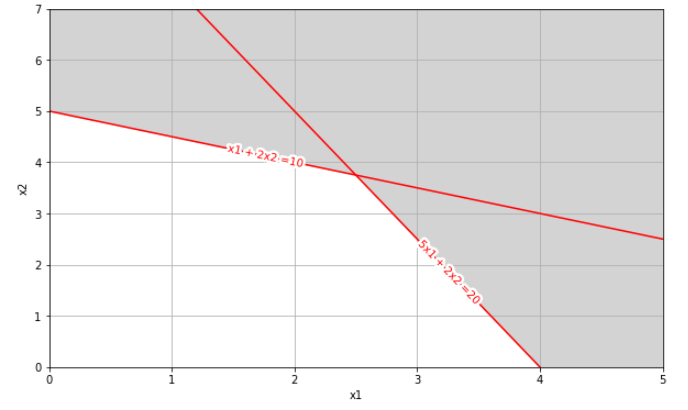
<blockquote>
On rajoute la contrainte, toutes les solutions à droite de la droite $x_1 = 2$ ne sont donc pas des solutions au problème $P_1'$ (représentées en vert)
    
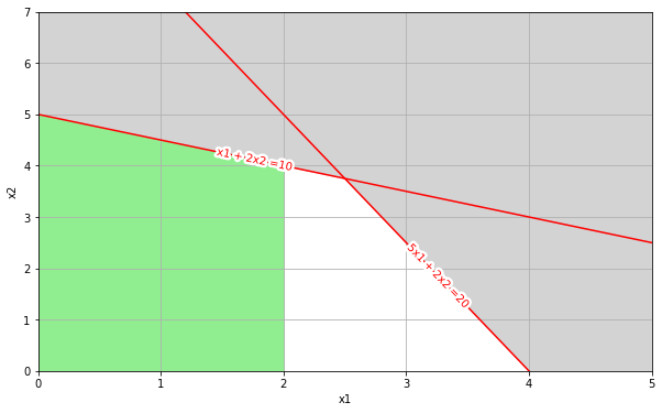
</blockquote>    



Vous avez juste ici le code pour résoudre le problème $P_0'$.
Ajoutez-y votre nouvelle contrainte afin d'obtenir la solution du problème $P_1'$.

In [40]:
from pulp import *
problem = LpProblem("Ex4", LpMaximize)

X1 = LpVariable("x1",0)
X2 = LpVariable("x2",0)

#Fonction objectif
problem += 13*X1 + 8*X2

#Contraintes
problem += 1*X1 + 2*X2 <= 10
problem += 5*X1 + 2*X2 <= 20
problem += \
X1 <= 2 # SOLUTION

problem.solve()

print("Status:", LpStatus[problem.status])
print("Valeur de la solution optimale = ", value(problem.objective))

for v in problem.variables():   
    print(v.name, "=", v.varValue)



ModuleNotFoundError: No module named 'pulp'

Que remarquez-vous ? Est-ce que cette solution est la solution optimale de $P_1$ ? Et de $P_0$, pourquoi ?

<blockquote>
    La solution optimale du problème $P_1'$ est entière. C'est donc évidemment la solution optimale pour $P_1$, car c'est le solveur qui l'a trouvée. Il est en revanche impossible de dire si c'est la solution optimale de $P_0$, car l'espace des solutions n'a pas été complètement exploré.
</blockquote>

Décrivez le problème $P_2$, qui est un autre sous problème de $P_0$ mais qui permet d'explorer le reste des solutions.
<blockquote>
Il faut rajouter la contrainte $x_1 \geq 3$. Certains étudiants seront sûrement tentés de proposer la contrainte $x_1 \geq 2$, mais il est important de préciser que $P_0$ ne peut pas avoir de solutions dans l'intervalle $]2,3[$.
</blockquote>

Utilisez le solveur pour résoudre $P_2'$.
<blockquote>
$X_1 = 3.0 \newline
X_2 = 2.5 \newline$
Valeur de la solution optimale = $59.0$
</blockquote>

Qu'observez-vous ? Rappelez ce que la valeur de cette solution implique sur la valeur de la solution optimale de $P_2$.
<blockquote>
Cette fois la solution n'est pas entière.
La valeur de toutes les solutions de $P_2$ est forcément inférieure ou égale à la valeur de la solution de $P_2'$, soit 59. 
</blockquote>

Continuez à résoudre $P_0$ en séparant cette fois ci $P_2$ en deux sous problèmes $P_3$ et $P_4$.
<blockquote>
Il faut proposer les sous problèmes :</br>
$P_3$ : Le problème $P_2$ + la contrainte : $x_2 \leq 2$ et </br>
$P_4$ : Le problème $P_2$ + la contrainte : $x_2 \geq 3$.
</blockquote>

Résolvez $P_3'$ à l'aide du solveur pulp? 
<blockquote>
$X_1 = 3.2 \newline
X_2 = 2.0 \newline$
Valeur de la solution optimale = $ 57.6\newline$
</blockquote>

La solution optimale pour $P_3'$ n'est donc pas une solution de $P_3$. Nous revoilà dans le même problème que pour $P_2$. En revanche, souvenez-vous, nous cherchons à résoudre $P_0$. Rappelez la valeur de la solution pour $P_1$. Comment exploiter cette valeur et la valeur de la solution de $P_3'$.
<blockquote>
Etant donné que la valeur de la solution optimale de $P_3$ est bornée par celle de $P_3'$, on sait qu'il n'existe pas de solutions à $P_3$ dont la valeur est meilleure que $57.6$. De plus comme nous sommes en train de chercher une solution au problème $P_0$ et que nous connaissons déjà une solution d'une meilleure valeur que $57.6$, il est en fait inutile d'explorer $P_3$ plus profondément. On peut stopper l'exploration de $P_3$ ici.
</blockquote>

Résolvez $P_4'$ à l'aide de pulp. Qu'observez-vous? Comment expliquer cette réponse du solveur?
<blockquote>
Le solveur indique : "Status: Undefined". En effet, les contraintes rajoutées font qu'il n'existe aucune solution à $P_4'$, donc à $P_4$.
</blockquote>


Quelle est donc la solution optimale au problème $P_0$?
<blockquote>
    C'est la solution du problème $P_1$, de valeur $58$.
    </blockquote>
    
Et voilà ! Vous avez déroulé l'algorithme du Branch and Bound sur un exemple simple. 
Pour résumer, il est en fait assez naturel de se dire qu'a chaque fois que l'on fait un choix de sous problème, on "branche" (imaginez un arbre de décision, comme pour la recherche exhaustive) notre problème. Ensuite, on calcul la valeur du sous problème relaxé qui est une "borne" (Bound en anglais) à la valeur du sous problème, et si cette borne n'est pas plus grande (dans le cas d'un problème de maximisation) que la meilleure solution trouvée, on n'explore pas la branche créée par ce sous problème.


# Utilisation des solveurs

Maintenant que nous comprenons pourquoi en théorie, le branch and bound qui est un l'un des meilleurs algorithme pour résoudre des PLNE, est tout de même de complexité exponentielle, nous allons voir comment l'utiliser en pratique.
Nous reprenons pour la dernière fois le problème du [sac à dos](https://fr.wikipedia.org/wiki/Probl%C3%A8me_du_sac_%C3%A0_dos).

On a implémenté lors du workshop 3 une modélisation pour traiter ce problème lorsque les variables ne sont pas entières. On sait aussi maintenant qu'il existe des algorithmes qui résolvent des programmes linéaires en nombre entier. Que se passerait-il si notre instance était trop longue à calculer? Que pourrait-on faire dans ce cas-là?

<blockquote>
Si le branch and bound ne termine pas, nous ne pourrons pas obtenir la solution optimale à notre problème. </br>
En revanche, il est toujours possible de trouver une solution approchée, soit par approche heuristique (comme dans le WS 2), soit en attendant que le branch and bound trouve au moins une solution, mais à nouveau cela peut être très long.
</blockquote>

Et puis, on ne sait pas non plus si ce qu'on obtient est représentatif. Après tout, on n'a traité qu'une seule instance. Peut-être qu'on a eu de la chance, et que cette instance était très facile. Ou au contraire, peut-être que les solutions à l'instance que l'on a construite étaient très difficiles à trouver, mais qu'on n'a pas eu de chance et qu'en général nos algorithmes se comportent plutôt bien.

Ce qu'il faudrait, c'est générer des instances aléatoires pour pouvoir produire quelques statistiques descriptives qui nous donneraient une idée de tout ça. On pourrait faire varier certains paramètres des instances générées (nombre d'objets, taille ou valeur maximale…) pour voir leur impact sur les algorithmes.

Et on peut aussi faire varier les paramètres des algorithmes eux-mêmes.

Pour commencer, on initialise des instances.


In [ ]:
import random
nb_obj = 100 
poids_min, poids_max, val_min, val_max = 500,1000,500,1000 
def create_items(nb_obj,poids_min, poids_max, val_min, val_max):
    return [ (random.randint(val_min,val_max),random.randint(poids_min,poids_max)) for _ in range(nb_obj)]

items = create_items(nb_obj,poids_min, poids_max, val_min, val_max)
print(items)

[(928, 799), (959, 845), (943, 637), (953, 991), (641, 675), (962, 885), (958, 786), (703, 655), (903, 817), (635, 765), (708, 912), (711, 653), (865, 577), (725, 859), (930, 972), (787, 977), (890, 839), (552, 501), (632, 942), (653, 669), (688, 921), (611, 737), (747, 687), (808, 771), (653, 700), (701, 788), (624, 978), (566, 779), (811, 709), (514, 988), (856, 982), (673, 875), (694, 588), (501, 634), (791, 724), (820, 612), (742, 636), (941, 722), (528, 511), (994, 544), (714, 789), (685, 726), (736, 950), (766, 581), (873, 793), (931, 693), (600, 759), (758, 534), (894, 722), (996, 547), (810, 746), (803, 591), (548, 506), (573, 826), (537, 673), (883, 640), (530, 882), (810, 545), (632, 757), (553, 986), (590, 533), (745, 985), (807, 763), (738, 816), (904, 824), (630, 671), (554, 980), (928, 883), (594, 907), (599, 663), (921, 851), (918, 742), (959, 607), (712, 904), (702, 934), (954, 920), (696, 584), (506, 799), (757, 833), (503, 990), (563, 745), (711, 919), (712, 792), (71

Puis, on utilise le module pulp pour résoudre le programme linéaire en nombre entier.

In [ ]:
from pulp import *

#Capacité du sac à dos
Capacity = 1000

#Initialisation du problème
prob = LpProblem("Pb", LpMaximize) 

#On utilise un dictionaire de variables
x = LpVariable.dicts('items', range(len(items)),
                            lowBound = 0,
                            upBound = 1,
                            cat = 'Integer')
#Fonction Economique
prob += lpSum([x[i]*items[i][0] for i in range(nb_obj)])
#Contrainte
prob += lpSum([x[i]*items[i][1] for i in range(nb_obj)]) <= Capacity
#Appel du solveur
prob.solve(GUROBI(Cuts=0,Presolve=0,Heuristics=0, OutputFlag=0))
#Affichage des résultats

print("Valeur de la fonction économique: ",value(prob.objective))


Restricted license - for non-production use only - expires 2025-11-24
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Gurobi status= 2
Valeur de la fonction économique:  996.0


Comme vous pouvez le voir, on peut déclarer directement des variables entières lorsque l'on utilise pulp. Eh oui, les solveurs sont capables de gérer des programmes linéaires en nombre entier ou d'un programme linéaire mixte. Les performances de ces solveurs sont différentes car ils font chacun leur cuisine interne qu'il est impossible de connaitre en détail (ce n'est pas pour rien que les solveurs les plus performants coutent des milliers d'euros), mais ils reposent tous à la base sur le principe du branch & bound. En revanche, il est possible, tout comme pour le branch and bound de comprendre et d'utiliser certaines options d'optimisation de ces solveurs.

Vous remarquerez aussi que le code n'est pas exactement le même que celui du workshop. Soyez sûr de bien le comprendre si vous voulez l'utiliser (ce qui est fortement conseillé car il est plus optimisé). Vous trouverez toutes les informations dont vous avez besoin sur les fonctions qui sont utilisées dans <a href="https://www.coin-or.org/PuLP/pulp.html"> la documentation de pulp</a>.

Maintenant que vous savez utiliser pulp, c'est à vous de jouer pour trouver un moyen d'utiliser les solveurs pour trouver des solutions approchées à des problèmes de PLNE, dans le cas où les instances seraient de trop grandes tailles... 